In [17]:
import pandas as pd
import plotly.express as px
import seaborn as sns
import matplotlib.pyplot as plt

In [18]:
df=pd.read_csv('ping_failures_jobtrace.csv')
df = df[df["job"] != 8338565]
df['timestamp'] = pd.to_datetime(df['timestamp']).dt.floor("s")
df.to_csv('jobs_with_ping_failures.csv')
df.tail()

,date,job,timestamp,Last_lost_communication_timestamp,Job_endtime,Elapsed_time_after_last_lostcomm(min),Lost communication with,Kill_job?,Exit_status,message
12288,20260328,8407006,2026-03-28 23:30:09,2026-03-28 23:30:11.592116,2026-03-28 23:49:13.318209,19.029,x4309c7s4b0n0,Yes,-29,2026-03-28 23:30:09.368821;mom_logs;x4312c3s6b...
12289,20260328,8405418,2026-03-28 11:53:44,2026-03-28 12:00:44.994983,2026-03-28 12:03:17.680661,2.545,x4308c5s4b0n0,Yes,-14,2026-03-28 11:53:44.512259;mom_logs;x4619c3s1b...
12290,20260328,8405982,2026-03-28 02:09:04,2026-03-28 02:09:50.977725,2026-03-28 02:12:03.153648,2.203,x4315c5s3b0n0,Yes,127,2026-03-28 02:09:04.924231;mom_logs;x4314c5s2b...
12291,20260328,8405301,2026-03-28 20:51:26,2026-03-28 20:58:27.205185,2026-03-28 21:01:09.662923,2.708,x4217c7s6b0n0,Yes,-14,2026-03-28 20:51:26.555790;mom_logs;x4203c7s3b...
12292,20260329,8406620,2026-03-29 09:02:14,2026-03-29 09:02:14.237782,2026-03-29 09:10:45.552966,8.522,x4019c6s0b0n0,Yes,127,2026-03-29 09:02:14.237782;mom_logs;x4305c0s1b...


In [19]:
#work with only unique jobs
df = df.drop_duplicates(subset="job", keep="first")

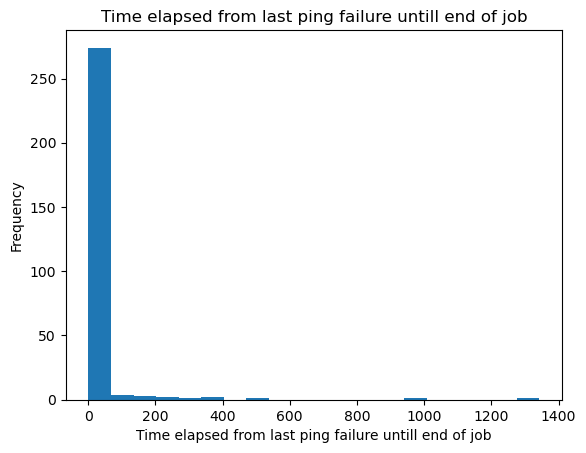

In [20]:
df["Elapsed_time_after_last_lostcomm(min)"] = pd.to_numeric(
    df["Elapsed_time_after_last_lostcomm(min)"], errors="coerce"
)
plt.figure()
plt.hist(df["Elapsed_time_after_last_lostcomm(min)"].dropna(), bins=20)
plt.xlabel("Time elapsed from last ping failure untill end of job")
plt.ylabel("Frequency")
plt.title("Time elapsed from last ping failure untill end of job")
plt.show()

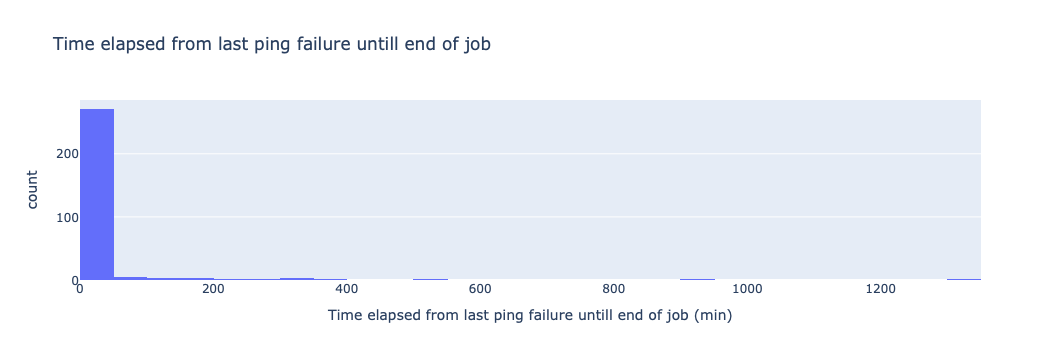

In [21]:
# Ensure column is numeric
df["Elapsed_time_after_last_lostcomm(min)"] = pd.to_numeric(
    df["Elapsed_time_after_last_lostcomm(min)"], errors="coerce"
)

df_clean = df[["Elapsed_time_after_last_lostcomm(min)"]].dropna()
fig = px.histogram(
    df_clean,
    x="Elapsed_time_after_last_lostcomm(min)",
    nbins=30,
    title="Time elapsed from last ping failure untill end of job",
    labels={"Elapsed_time_after_last_lostcomm(min)": "Time elapsed from last ping failure untill end of job (min)"}
)

fig.show()
fig.write_html('last_ping_until_jobend')

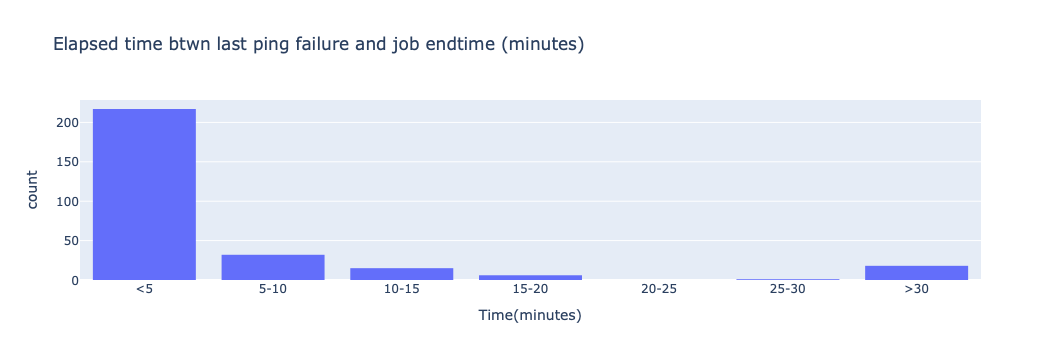

In [22]:
import plotly.express as px
import pandas as pd

# Ensure the column is numeric
df["Elapsed_time_after_last_lostcomm(min)"] = pd.to_numeric(
    df["Elapsed_time_after_last_lostcomm(min)"], errors="coerce"
)

df_clean = df[["Elapsed_time_after_last_lostcomm(min)"]].dropna()

bins = [0, 5, 10, 15, 20, 25, 30, df_clean["Elapsed_time_after_last_lostcomm(min)"].max() + 1]

labels = ["<5", "5-10", "10-15", "15-20", "20-25", "25-30", ">30"]

# Create ordered categorical column
df_clean["Elapsed_bin"] = pd.cut(
    df_clean["Elapsed_time_after_last_lostcomm(min)"],
    bins=bins,
    labels=labels,
    right=False,
    ordered=True
)

# Plot histogram 
fig = px.histogram(
    df_clean,
    x="Elapsed_bin",
    category_orders={"Elapsed_bin": labels}, 
    title="Elapsed time btwn last ping failure and job endtime (minutes)",
    labels={"Elapsed_bin": "Time(minutes)", "count": "Frequency"}
)

fig.show()

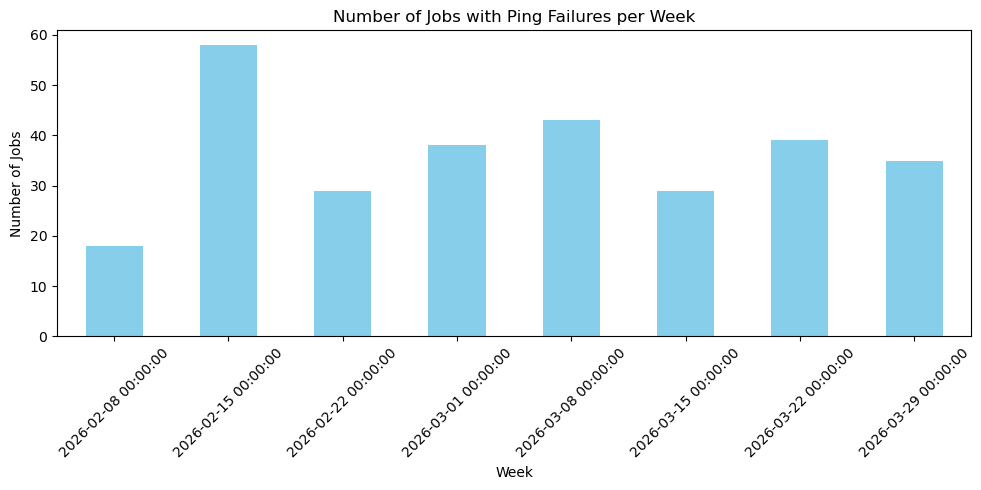

In [23]:
#plot number of jobs with ping failures per week
df = df.set_index("timestamp")
jobs_per_week = df.resample("W")["job"].count()
plt.figure(figsize=(10,5))
jobs_per_week.plot(kind="bar", color="skyblue")
plt.title("Number of Jobs with Ping Failures per Week")
plt.xlabel("Week")
plt.ylabel("Number of Jobs")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

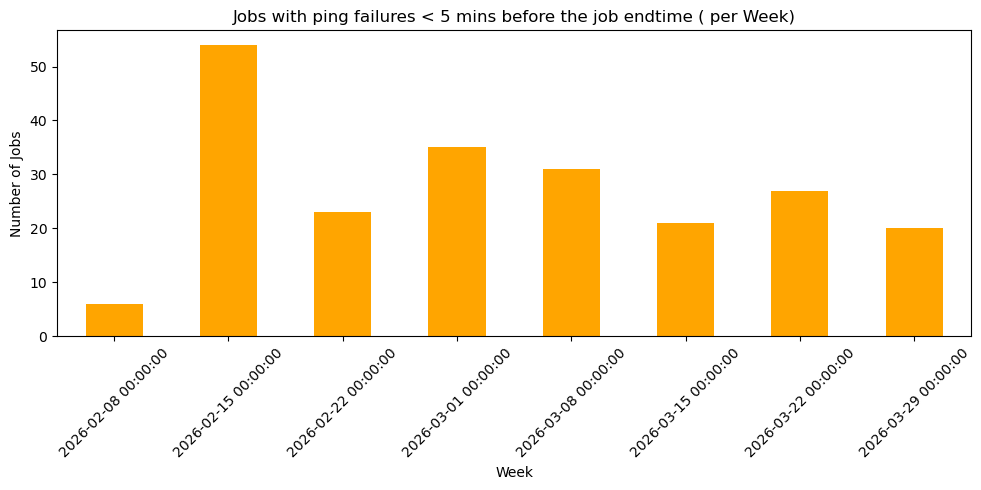

In [24]:
#plot number of jobs with ping failures per week with ping failures close to the end of job
ping_failures_close_to_jobendtime = df[df["Elapsed_time_after_last_lostcomm(min)"] < 5]

ping_failures_close_to_jobendtime_per_week = ping_failures_close_to_jobendtime.resample("W")["Elapsed_time_after_last_lostcomm(min)"].count()

plt.figure(figsize=(10,5))
ping_failures_close_to_jobendtime_per_week.plot(kind="bar", color="orange")
plt.title("Jobs with ping failures < 5 mins before the job endtime ( per Week)")
plt.xlabel("Week")
plt.ylabel("Number of Jobs")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()